In [43]:
from joblib import load
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

## Loading Models

In [44]:
log_model = load("../models/logistic_regression.pkl")
tree_model = load("../models/decision_tree.pkl")
rf_model = load("../models/random_forest.pkl")

/opt/miniconda3/envs/student-performance/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Loading validation data

In [45]:

X_val = pd.read_csv("../data/processed/X_val.csv")
y_val = pd.read_csv("../data/processed/y_val_class.csv")

y_val = y_val.squeeze()

print(X_val.shape)
print(y_val.shape)

(157, 43)
(157,)


## Predictions

In [46]:
log_pred = log_model.predict(X_val)
tree_pred = tree_model.predict(X_val)
rf_pred = rf_model.predict(X_val)

print("Predictions done")

Predictions done


/opt/miniconda3/envs/student-performance/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


## Comparing Accuracy

In [47]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_val, log_pred),
        accuracy_score(y_val, tree_pred),
        accuracy_score(y_val, rf_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.554140
1,Decision Tree,0.503185
2,Random Forest,0.605096


## Visual Comparasions

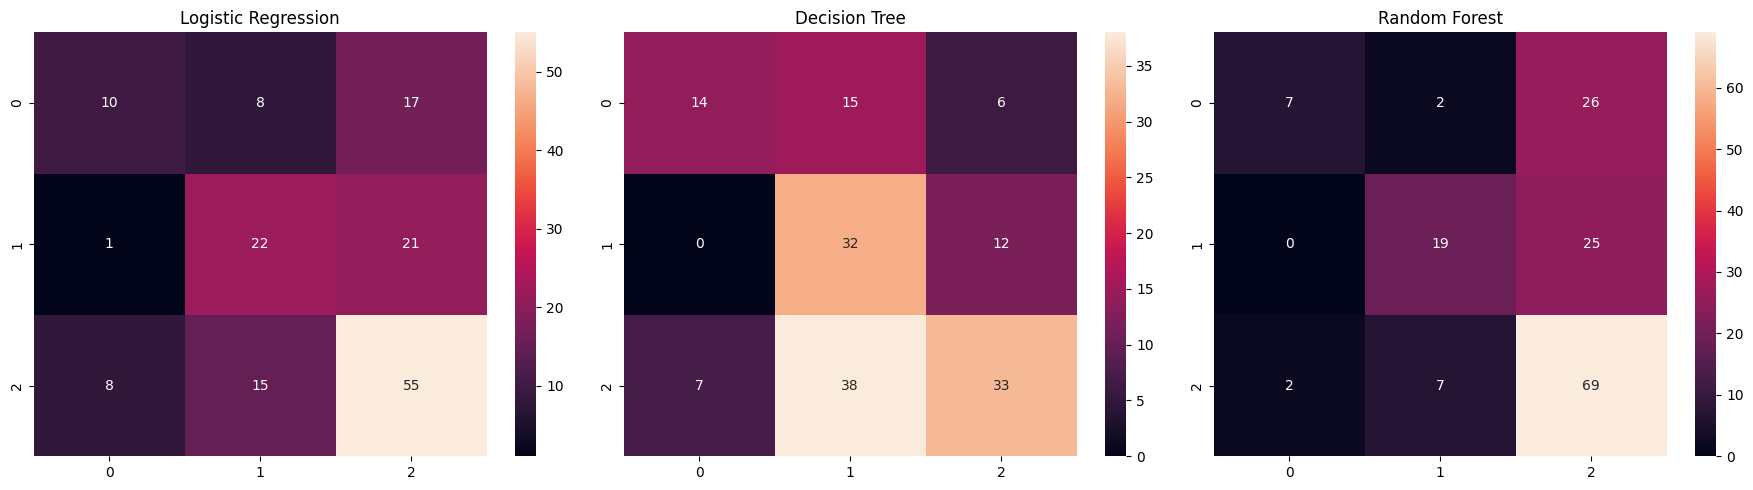

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

preds = [log_pred, tree_pred, rf_pred]
titles = ["Logistic Regression", "Decision Tree", "Random Forest"]

for i in range(3):
    cm = confusion_matrix(y_val, preds[i])
    sns.heatmap(cm, annot=True, fmt="d", ax=axes[i])
    axes[i].set_title(titles[i])

plt.tight_layout()
plt.show()

## Classification Reports

In [49]:
print("Logistic Regression:\n")
print(classification_report(y_val, log_pred))

print("\nDecision Tree:\n")
print(classification_report(y_val, tree_pred))

print("\nRandom Forest:\n")
print(classification_report(y_val, rf_pred))

Logistic Regression:

              precision    recall  f1-score   support

        High       0.53      0.29      0.37        35
         Low       0.49      0.50      0.49        44
      Medium       0.59      0.71      0.64        78

    accuracy                           0.55       157
   macro avg       0.54      0.50      0.50       157
weighted avg       0.55      0.55      0.54       157


Decision Tree:

              precision    recall  f1-score   support

        High       0.67      0.40      0.50        35
         Low       0.38      0.73      0.50        44
      Medium       0.65      0.42      0.51        78

    accuracy                           0.50       157
   macro avg       0.56      0.52      0.50       157
weighted avg       0.58      0.50      0.50       157


Random Forest:

              precision    recall  f1-score   support

        High       0.78      0.20      0.32        35
         Low       0.68      0.43      0.53        44
      Medium       

## Best model selection

In [50]:
best_model = rf_model

with open("../models/final_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Final model: Random Forest")

Final model: Random Forest


## Precision-Recall comparison per class

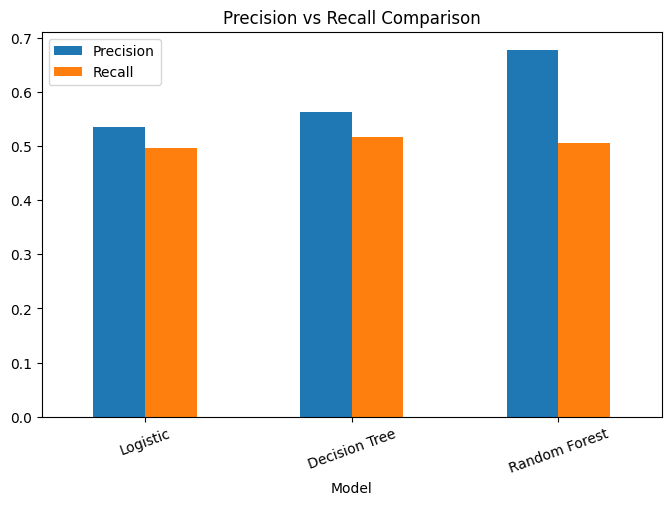

In [51]:
models = ["Logistic", "Decision Tree", "Random Forest"]
preds = [log_pred, tree_pred, rf_pred]

precision = [precision_score(y_val, p, average='macro') for p in preds]
recall = [recall_score(y_val, p, average='macro') for p in preds]

df_metrics = pd.DataFrame({
    "Model": models,
    "Precision": precision,
    "Recall": recall
})

df_metrics.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Precision vs Recall Comparison")
plt.xticks(rotation=20)
plt.show()

The Random Forest model performs best overall, achieving the highest accuracy and balanced precision and recall across classes. Logistic Regression underperforms, especially in identifying high-risk students, while Decision Tree shows unstable behavior. Therefore, Random Forest is selected as the final model.

# Model Comparison Summary

- Logistic Regression achieved ~55% accuracy and low recall for High Risk students.
- Decision Tree showed unstable performance and lower overall accuracy.
- Random Forest achieved the highest accuracy (~61%) and better overall balance across classes.

Final model selected: Random Forest

Reason:
- Highest validation accuracy
- More consistent performance across classes
- Better ability to identify high-risk students compared to other models